# Exploring the simulation results

Inspects the output of `simulate.py` for one beam population: the `example_meta.pkl`  contains the sampled parameters, natural frequencies, mode shapes while `example_data.pkl` contains acceleration / velocity / displacement time histories.

The notebook goes through the population in three steps:

1. **Sampled parameters**: distributions of the beam geometry (`b0`, `h0`, `L`), the force amplitude `F` and the number of simultaneous excitation points `n_loads`, to check what the Sobol sampling actually covered.
2. **Modal properties**: the first three natural frequencies against beam length and against system index, the mode shapes of one random system, and the normalized mode shapes of the whole population, to see how much modal variability the dataset contains.
3. **Time histories**: the response of one system in time and in frequency (Welch PSD across all nodes, then a few nodes side by side), to confirm the excited modes show up in the signals.


In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

plt.rcParams.update({
    "axes.grid": True, "grid.alpha": 0.4,
})
ACCENT = "#4C72B0"
FS = 500

simulation_dir = Path("../simulationResults")
name = "example"
df   = pd.read_pickle(simulation_dir / f"{name}_meta.pkl")
data = pd.read_pickle(simulation_dir / f"{name}_data.pkl")

print(f"Systems : {len(df)}")
print(f"Columns : {list(df.columns)}")

Systems : 4000
Columns : ['E', 'b0', 'h0', 'L', 'rho', 'zeta', 'db', 'dh', 'l_taper_start', 'L_embedded', 'k_x', 'k_r', 'm_tip', 'F', 'f0', 'n_loads', 'target_nodes', 'mode_shapes']


## Sampled parameters

What the Sobol sampler actually drew: the beam cross-section and length, the amplitude of the applied force, and how many nodes are excited at the same time across the population.

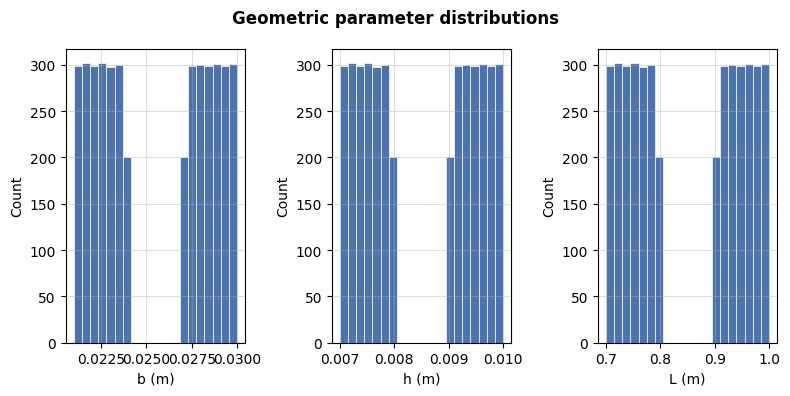

In [2]:
# Geometric parameter distributions: b, h, L
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
for ax, (col, label) in zip(axes, [("b0", "b (m)"), ("h0", "h (m)"), ("L", "L (m)")]):
    ax.hist(df[col], bins=20, color=ACCENT, edgecolor="white", linewidth=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
fig.suptitle("Geometric parameter distributions", fontweight="bold")
fig.tight_layout()
plt.show()

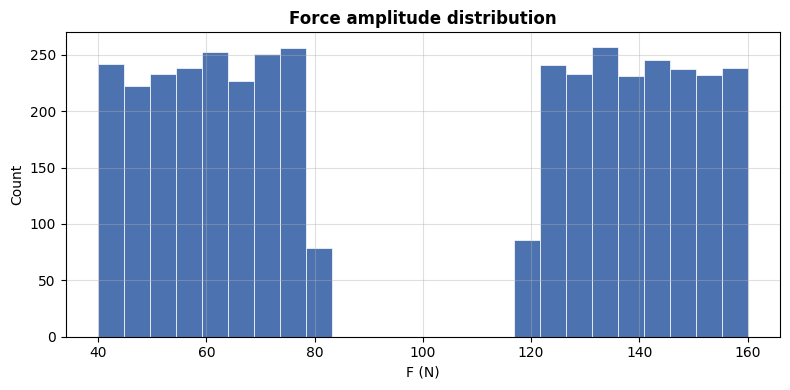

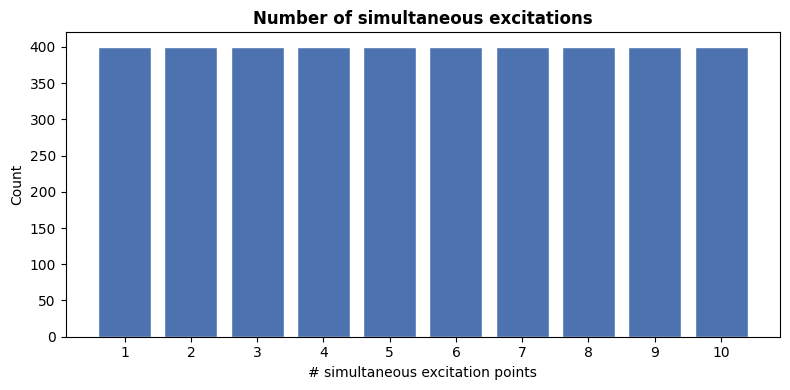

In [3]:
# force amplitude distribution
F0 = df.F.apply(lambda x: x[0] if len(x) > 0 else np.nan).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(F0, bins=25, color=ACCENT, edgecolor="white", linewidth=0.5)
ax.set_xlabel("F (N)")
ax.set_ylabel("Count")
ax.set_title("Force amplitude distribution", fontweight="bold")
fig.tight_layout()
plt.show()

# number of simultaneous excitations
c = df.n_loads.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(c.index, c.values, color=ACCENT, edgecolor="white", width=0.8)
ax.set_xlabel("# simultaneous excitation points")
ax.set_ylabel("Count")
ax.set_title("Number of simultaneous excitations", fontweight="bold")
ax.set_xticks(c.index)
ax.grid(axis="y")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Modal properties

The first three natural frequencies of every system, plotted against beam length and against system index. Additionally, the mode shapes of one randomly picked system.

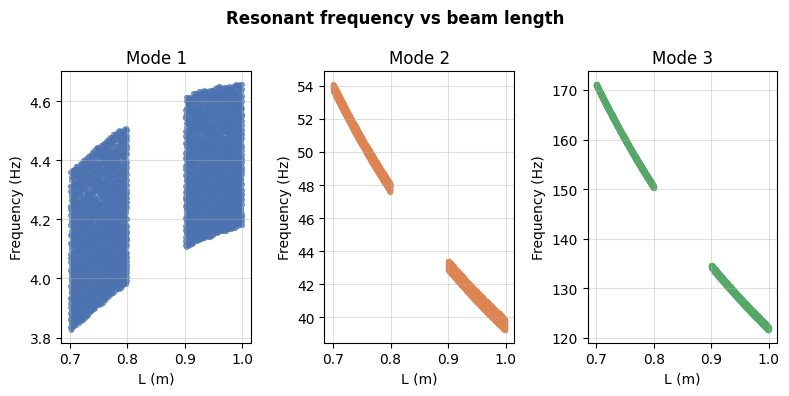

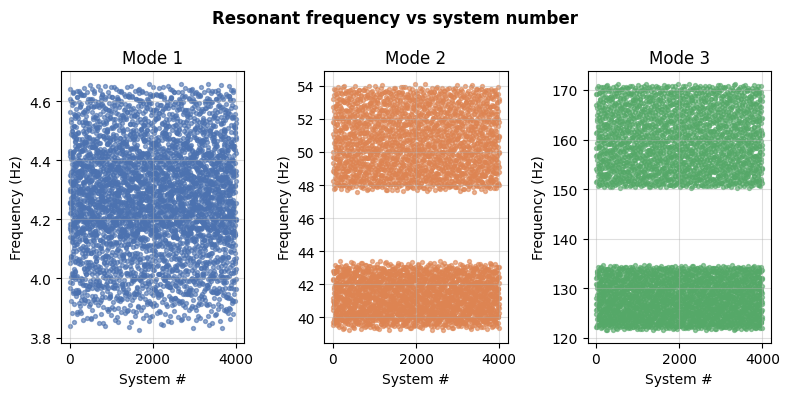

In [4]:
# resonant frequencies across the population
f0_array = np.stack([f[:3] for f in df.f0.values])
colors = ["#4C72B0", "#DD8452", "#55A868"]
mode_labels = ["Mode 1", "Mode 2", "Mode 3"]

# f_i against lenght
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
for i, (ax, c, lbl) in enumerate(zip(axes, colors, mode_labels)):
    ax.scatter(df.L, f0_array[:, i], s=8, color=c, alpha=0.6)
    ax.set_xlabel("L (m)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(lbl)
    ax.ticklabel_format(useOffset=False, axis='y')
fig.suptitle("Resonant frequency vs beam length", fontweight="bold")
fig.tight_layout()
plt.show()

# vs system number
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
for i, (ax, c, lbl) in enumerate(zip(axes, colors, mode_labels)):
    ax.scatter(range(len(df)), f0_array[:, i], s=8, color=c, alpha=0.6)
    ax.set_xlabel("System #")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(lbl)
    ax.ticklabel_format(useOffset=False, axis='y')
fig.suptitle("Resonant frequency vs system number", fontweight="bold")
fig.tight_layout()
plt.show()

[  4.12997436  53.67176428 170.21337112 352.80456706 601.21809374]


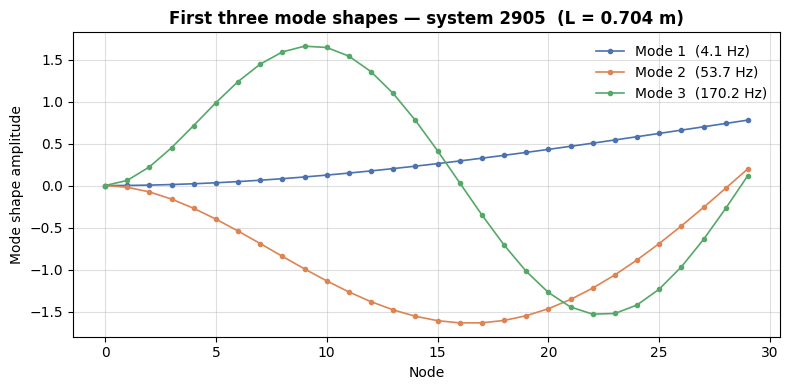

In [ ]:
# first three mode shapes for random system
rng = np.random.default_rng(4)
rand_idx = int(rng.choice(len(df)))
shapes   = df.mode_shapes[rand_idx]
nodes    = np.arange(shapes.shape[1])
print(df.f0[rand_idx])
fig, ax = plt.subplots(figsize=(8, 4))
for i, (c, lbl) in enumerate(zip(colors, mode_labels)):
    ax.plot(nodes, shapes[i], "o-", color=c, markersize=3, linewidth=1.2,
            label=f"{lbl}  ({df.f0[rand_idx][i]:.1f} Hz)")
ax.set_xlabel("Node")
ax.set_ylabel("Mode shape amplitude")
ax.set_title(f"First three mode shapes - system {rand_idx}  (L = {df.L[rand_idx]:.3f} m)",
             fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Time histories of one system
Acceleration response of the same random system: first the Welch PSD of all 30 nodes overlaid and coloured by node, then the time domain response and PSD of four nodes along the beam.

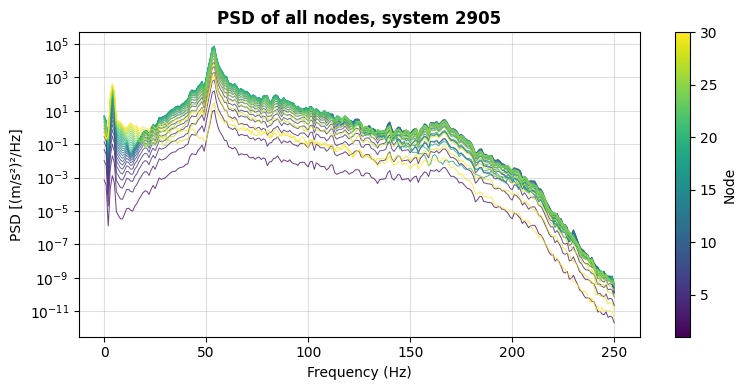

In [6]:
# psd of all nodes
acc_z    = data.acc_z[rand_idx]
welch_kw = dict(fs=FS, window="hann", nperseg=FS, noverlap=FS // 2)
cmap     = plt.cm.viridis(np.linspace(0, 1, 30))

fig, ax = plt.subplots(figsize=(8, 4))
for node in range(30):
    f, psd = welch(acc_z[node], **welch_kw)
    ax.semilogy(f, psd, color=cmap[node], linewidth=0.7, alpha=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD [(m/s²)²/Hz]")
ax.set_title(f"PSD of all nodes, system {rand_idx}", fontweight="bold")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(1, 30))
fig.colorbar(sm, ax=ax, label="Node")
fig.tight_layout()
plt.show()

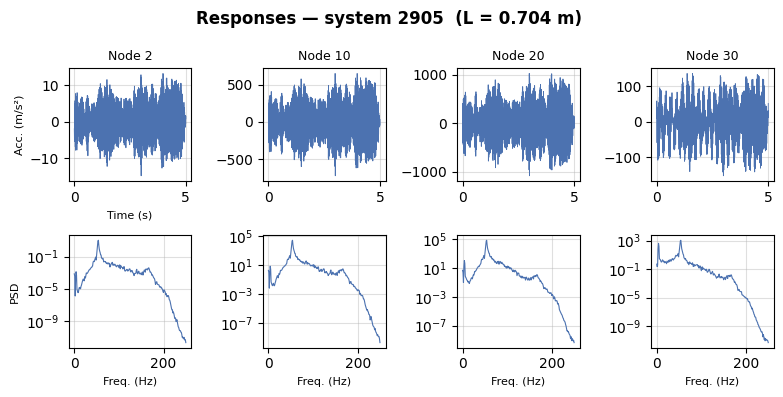

In [ ]:
# time response for some nodes
t = np.linspace(0, 5, acc_z.shape[1])
plot_nodes = [1, 9, 19, 29]

fig, axes = plt.subplots(2, len(plot_nodes), figsize=(8, 4), sharex="row")
for j, node in enumerate(plot_nodes):
    # time domain
    axes[0, j].plot(t, acc_z[node], color=ACCENT, linewidth=0.6)
    axes[0, j].set_title(f"Node {node + 1}", fontsize=9)
    if j == 0:
        axes[0, j].set_ylabel("Acc. (m/s²)", fontsize=8)

    # PSD
    f, psd = welch(acc_z[node], **welch_kw)
    axes[1, j].semilogy(f, psd, color=ACCENT, linewidth=0.8)
    axes[1, j].set_xlabel("Freq. (Hz)", fontsize=8)
    if j == 0:
        axes[1, j].set_ylabel("PSD", fontsize=8)

axes[0, 0].set_xlabel("Time (s)", fontsize=8)
fig.suptitle(f"Responses - system {rand_idx}  (L = {df.L[rand_idx]:.3f} m)", fontweight="bold")
fig.tight_layout()
plt.show()

## Mode shape variability across the population

Every system mode shapes, peak normalized so they can be compared. The first three modes are overlaid for the whole population, and the last plot subtracts the 1t mode shape of system 0 from all the others and colours the differences by tip mass `m_tip`.

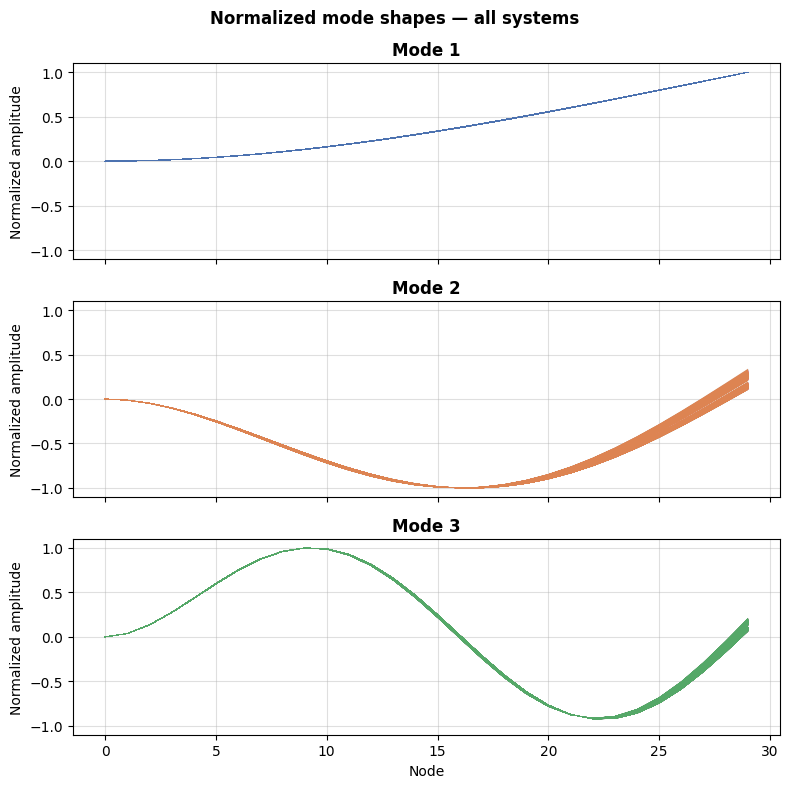

In [ ]:
# normalized mode shapes - all systems
all_shapes = np.stack(df.mode_shapes.values)   # (N, 5, n_nodes)
nodes = np.arange(all_shapes.shape[2])

peak = np.abs(all_shapes).max(axis=2, keepdims=True)
shapes_norm = all_shapes / peak

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
for i, (ax, c, lbl) in enumerate(zip(axes, colors, mode_labels)):
    for j in range(shapes_norm.shape[0]):
        ax.plot(nodes, shapes_norm[j, i], color=c, linewidth=0.3, alpha=0.2)
    ax.set_ylabel("Normalized amplitude")
    ax.set_title(lbl, fontweight="bold")
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel("Node")
fig.suptitle("Normalized mode shapes - all systems", fontweight="bold")
fig.tight_layout()
plt.show()

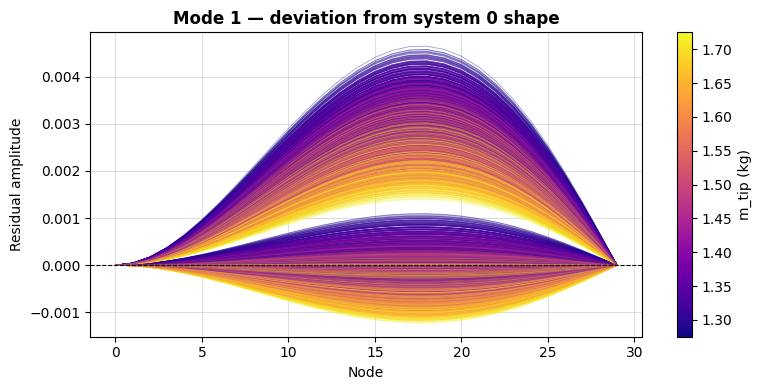

In [ ]:
# Mode 1 variation - residuals from first system shape, colored by tip mass m_tip
m_tip = df.m_tip.values
s1 = shapes_norm[:, 0, :]          # (N, n_nodes) - normalized mode 1
ref_s1 = s1[0]                     # reference: first system's shape
residuals = s1 - ref_s1            # deviation from reference system

norm_mtip = plt.Normalize(m_tip.min(), m_tip.max())
cmap_mtip = plt.cm.plasma

fig, ax = plt.subplots(figsize=(8, 4))
for j in range(s1.shape[0]):
    ax.plot(nodes, residuals[j], color=cmap_mtip(norm_mtip(m_tip[j])), linewidth=0.6, alpha=0.4)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
ax.set_ylabel("Residual amplitude")
ax.set_xlabel("Node")
ax.set_title("Mode 1 - deviation from system 0 shape", fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap_mtip, norm=norm_mtip)
fig.colorbar(sm, ax=ax, label="m_tip (kg)")
fig.tight_layout()
plt.show()
